### 1. Подготовка среды

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.metrics import accuracy_score
import time

# Настройка графиков
plt.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

### 2. Генерация и визуализация наборов данных

In [10]:
# 1. ЛИНЕЙНО РАЗДЕЛИМЫЙ НАБОР
X_linear, y_linear = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=2.0, random_state=42
)

# 2. НАБОР С ПЕРЕКРЫТИЕМ
X_overlap, y_overlap = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.3, flip_y=0.2, random_state=42
)

# 3. НЕЛИНЕЙНЫЙ НАБОР
X_nonlinear, y_nonlinear = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=2, class_sep=1.2, random_state=42
)

print("Наборы данных созданы:")
print(f"Линейный: {X_linear.shape}")
print(f"С перекрытием: {X_overlap.shape}")
print(f"Нелинейный: {X_nonlinear.shape}")

Наборы данных созданы:
Линейный: (100, 2)
С перекрытием: (100, 2)
Нелинейный: (200, 2)


#### 2.1. Линейно разделимый набор

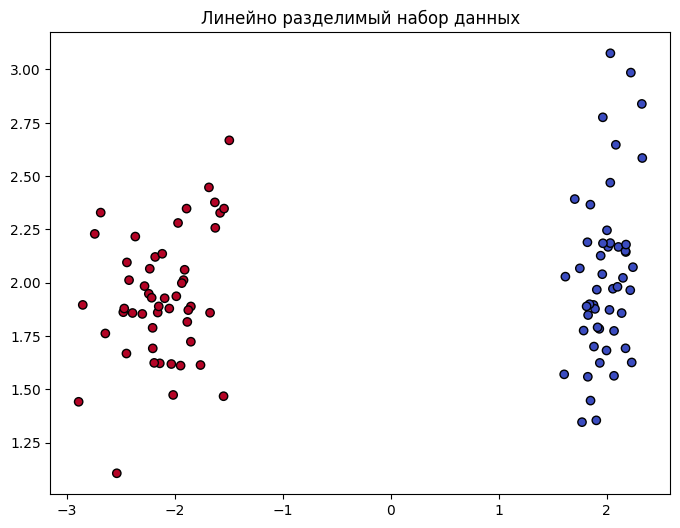

In [11]:
# Генерация данных
X1, y1 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.0,  # увеличенное разделение
    random_state=1
)

# Визуализация
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='coolwarm', edgecolors='k')
plt.title('Линейно разделимый набор данных')
plt.show()

#### 2.2. Набор с шумом (перекрытие классов)

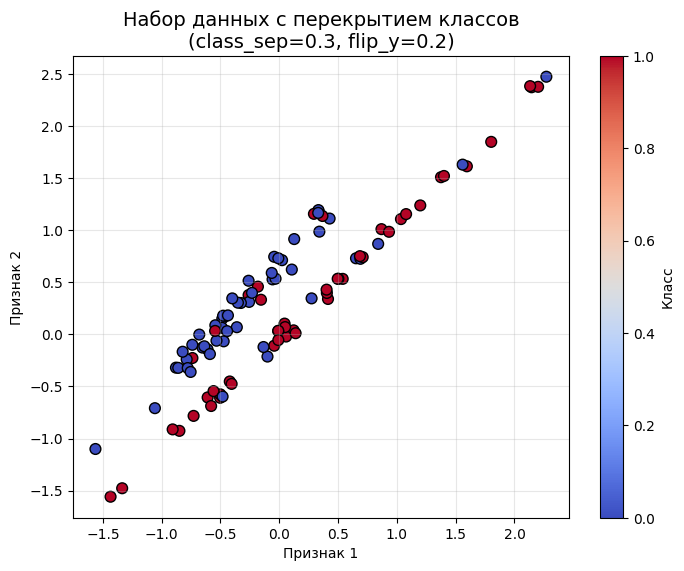

In [12]:
X1, y1 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.3,  # сильное уменьшение разделения
    flip_y=0.2,     # добавление шума - перекрытие классов
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='coolwarm', edgecolors='k', s=60)
plt.title('Набор данных с перекрытием классов\n(class_sep=0.3, flip_y=0.2)', fontsize=14)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Класс')
plt.savefig('overlap_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.3. Нелинейно разделимый набор

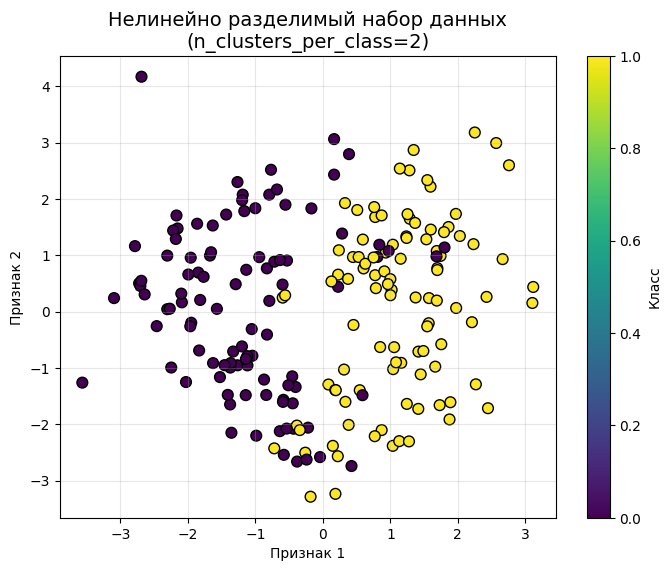

In [13]:
X1, y1 = make_classification(
    n_samples=200,  # увеличим количество samples для лучшей визуализации
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,  # два кластера на класс - создает нелинейность
    class_sep=1.2,
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='viridis', edgecolors='k', s=60)
plt.title('Нелинейно разделимый набор данных\n(n_clusters_per_class=2)', fontsize=14)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Класс')
plt.savefig('nonlinear_dataset_v1.png', dpi=300, bbox_inches='tight')
plt.show()

### 3. Обучение SVM на разных ядрах

3.1. Напишите функцию для обучения SVM и визуализации границы принятия решений:

In [14]:
def train_svm_and_plot_decision_boundary(X, y, kernel='rbf', C=1.0, gamma='scale', degree=3, title=""):
    """
    Обучает SVM и визуализирует границу принятия решений
    """
    try:
        # Масштабирование признаков
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.3, random_state=42
        )
        
        # Создание и обучение SVM модели
        if kernel == 'poly':
            svm_model = svm.SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, random_state=42)
        else:
            svm_model = svm.SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
        
        start_time = time.time()
        svm_model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Предсказание на тестовой выборке
        y_pred = svm_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Визуализация
        plt.figure(figsize=(10, 8))
        
        # Создание сетки для построения границ
        x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
        y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        
        # Предсказание для каждой точки сетки
        Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Построение контуров
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        
        # Точки данных
        scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', 
                             edgecolors='k', s=60, alpha=0.8)
        
        # Выделение опорных векторов
        plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
                    s=150, facecolors='none', edgecolors='yellow', 
                    linewidths=2, label='Опорные векторы')
        
        # Настройка графика
        plt.colorbar(scatter, label='Класс')
        plt.xlabel('Признак 1 (масштабированный)')
        plt.ylabel('Признак 2 (масштабированный)')
        
        # Заголовок с информацией о модели
        full_title = f"{title}\nЯдро: {kernel}, C: {C}, gamma: {gamma}"
        if kernel == 'poly':
            full_title += f", degree: {degree}"
        full_title += f"\nAccuracy: {accuracy:.3f}, Опорных векторов: {len(svm_model.support_vectors_)}"
        
        plt.title(full_title, fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Вывод информации о модели
        print(f"=== РЕЗУЛЬТАТЫ SVM ===")
        print(f"Ядро: {kernel}")
        print(f"Параметры: C={C}, gamma={gamma}" + (f", degree={degree}" if kernel == 'poly' else ""))
        print(f"Точность на тесте: {accuracy:.4f}")
        print(f"Время обучения: {training_time:.4f}с")
        print(f"Количество опорных векторов: {len(svm_model.support_vectors_)}")
        print("=" * 50)
        
        # Возвращаем результаты
        return svm_model, accuracy, training_time
        
    except Exception as e:
        print(f"Ошибка: {e}")
        return None, None, None

3.2. Примените созданную функцию к каждому набору данных с разными ядрами:

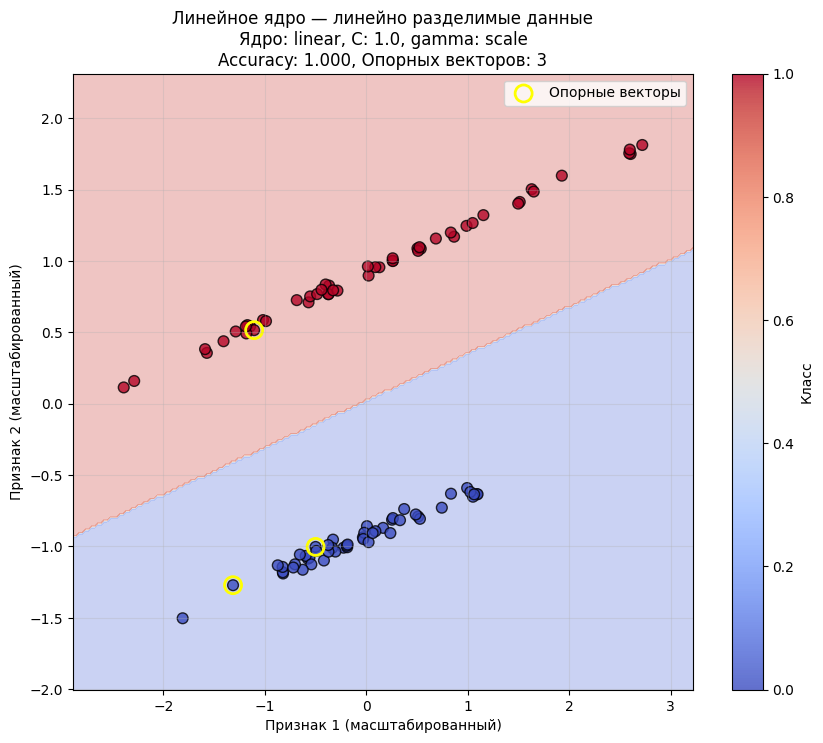

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: linear
Параметры: C=1.0, gamma=scale
Точность на тесте: 1.0000
Время обучения: 0.0030с
Количество опорных векторов: 3


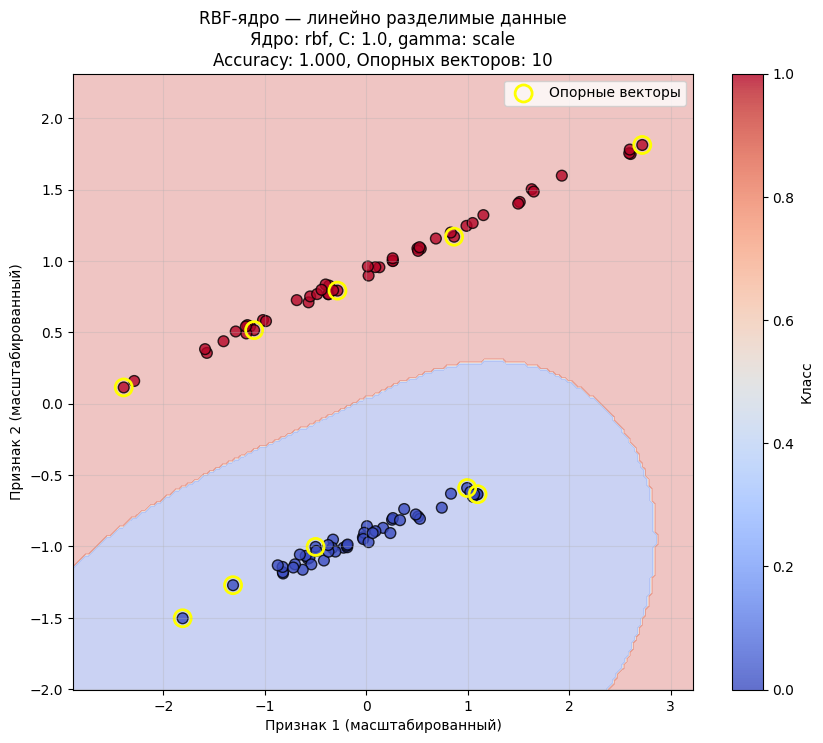

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: rbf
Параметры: C=1.0, gamma=scale
Точность на тесте: 1.0000
Время обучения: 0.0020с
Количество опорных векторов: 10


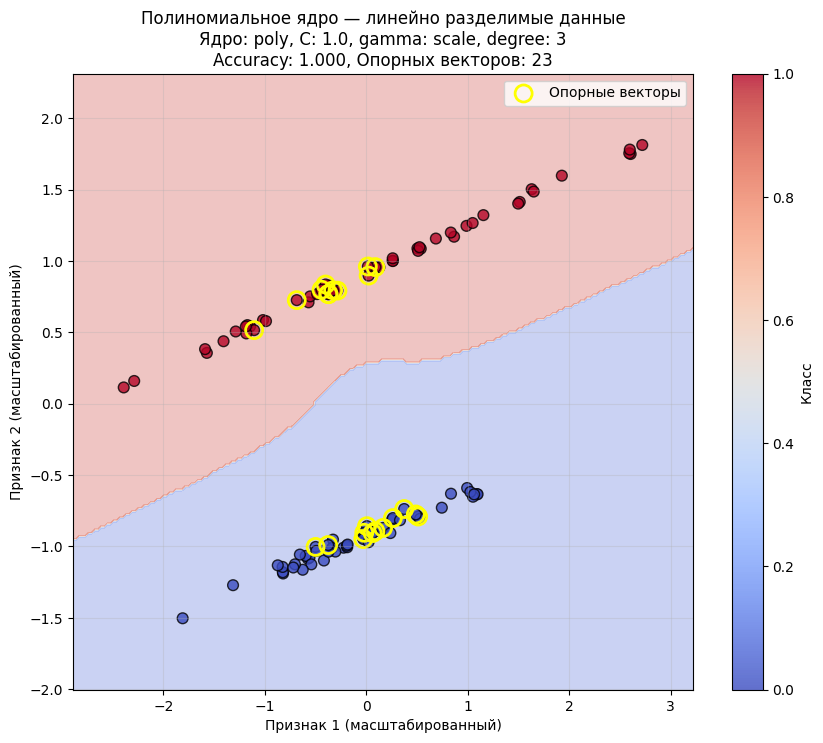

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: poly
Параметры: C=1.0, gamma=scale, degree=3
Точность на тесте: 1.0000
Время обучения: 0.0020с
Количество опорных векторов: 23


In [15]:
# Линейное ядро
model_linear_1, acc_linear_1, time_linear_1 = train_svm_and_plot_decision_boundary(
    X_linear, y_linear, 
    kernel='linear', 
    C=1.0,
    title='Линейное ядро — линейно разделимые данные'
)

# RBF ядро
model_rbf_1, acc_rbf_1, time_rbf_1 = train_svm_and_plot_decision_boundary(
    X_linear, y_linear, 
    kernel='rbf', 
    C=1.0, gamma='scale',
    title='RBF-ядро — линейно разделимые данные'
)

# Полиномиальное ядро
model_poly_1, acc_poly_1, time_poly_1 = train_svm_and_plot_decision_boundary(
    X_linear, y_linear, 
    kernel='poly', 
    C=1.0, gamma='scale', degree=3,
    title='Полиномиальное ядро — линейно разделимые данные'
)

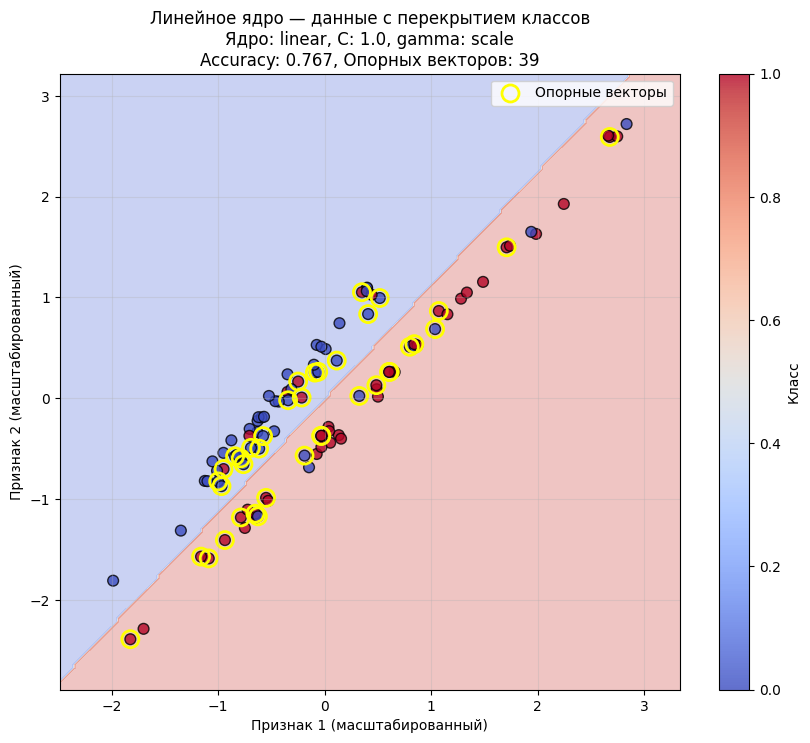

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: linear
Параметры: C=1.0, gamma=scale
Точность на тесте: 0.7667
Время обучения: 0.0028с
Количество опорных векторов: 39


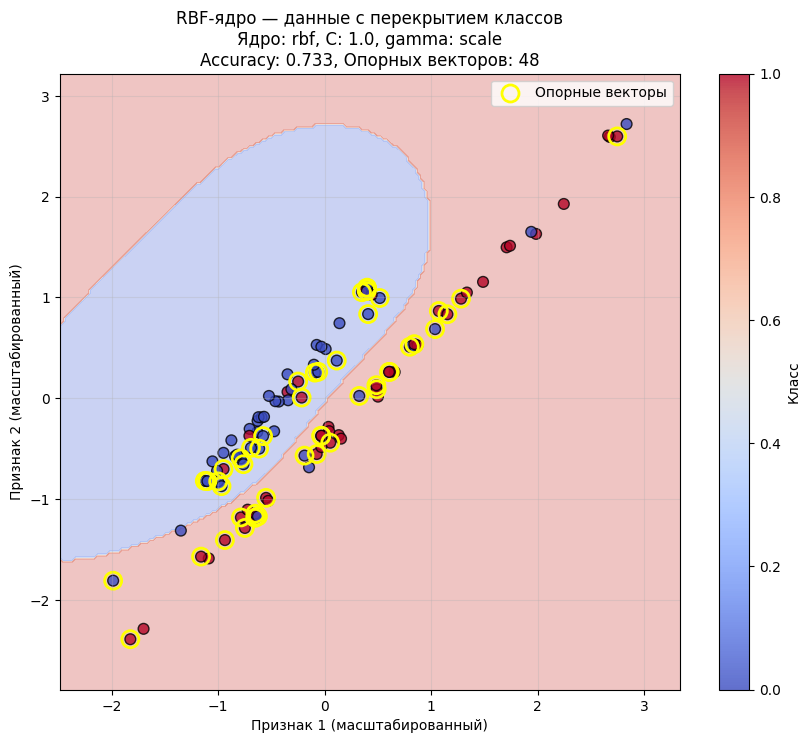

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: rbf
Параметры: C=1.0, gamma=scale
Точность на тесте: 0.7333
Время обучения: 0.0020с
Количество опорных векторов: 48


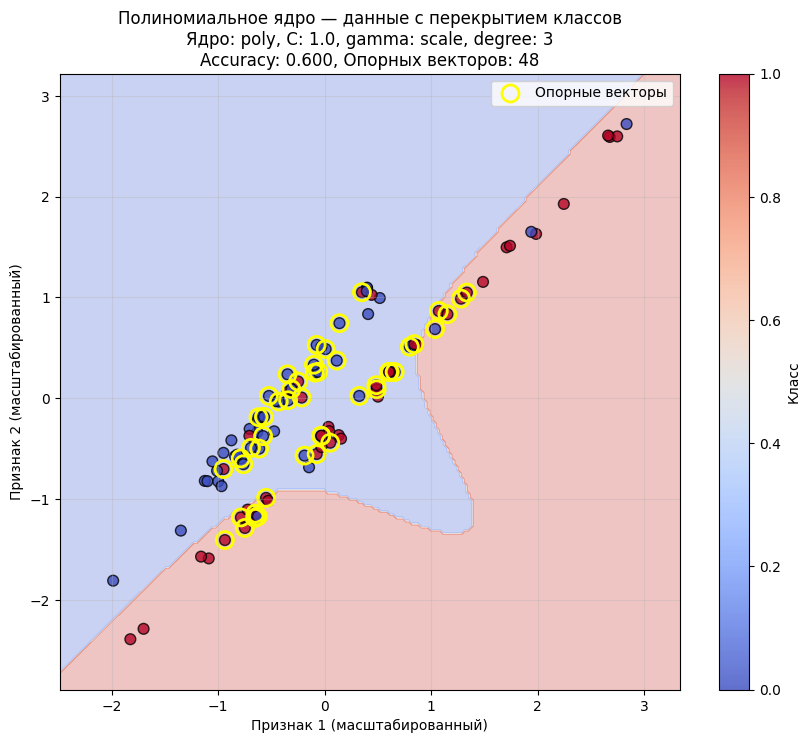

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: poly
Параметры: C=1.0, gamma=scale, degree=3
Точность на тесте: 0.6000
Время обучения: 0.0020с
Количество опорных векторов: 48


In [16]:
# С ПЕРЕКРЫТИЕМ
# Линейное ядро
model_linear_2, acc_linear_2, time_linear_2 = train_svm_and_plot_decision_boundary(
    X_overlap, y_overlap, 
    kernel='linear', 
    C=1.0,
    title='Линейное ядро — данные с перекрытием классов'
)

# RBF ядро
model_rbf_2, acc_rbf_2, time_rbf_2 = train_svm_and_plot_decision_boundary(
    X_overlap, y_overlap, 
    kernel='rbf', 
    C=1.0, gamma='scale',
    title='RBF-ядро — данные с перекрытием классов'
)

# Полиномиальное ядро
model_poly_2, acc_poly_2, time_poly_2 = train_svm_and_plot_decision_boundary(
    X_overlap, y_overlap, 
    kernel='poly', 
    C=1.0, gamma='scale', degree=3,
    title='Полиномиальное ядро — данные с перекрытием классов'
)

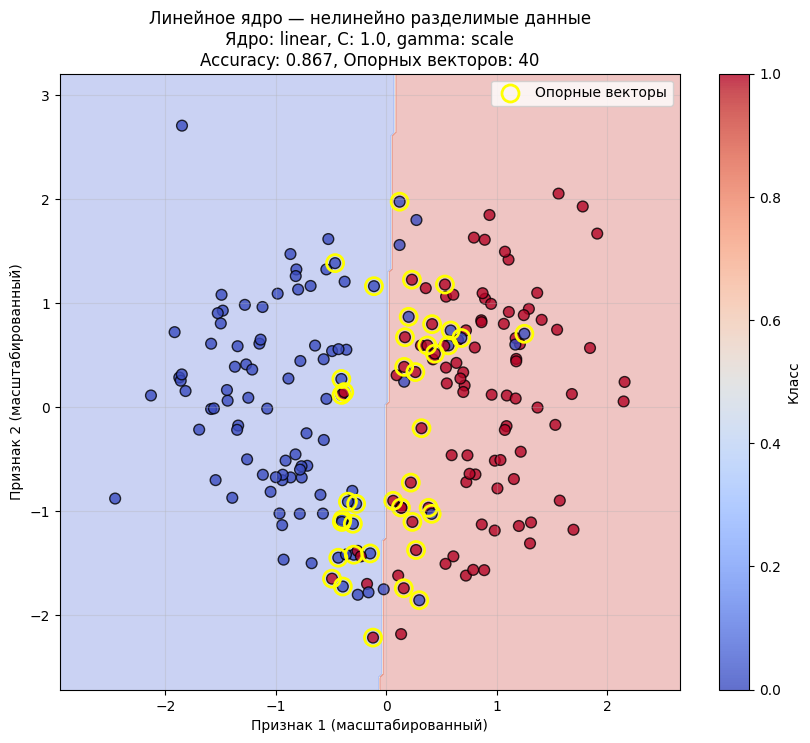

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: linear
Параметры: C=1.0, gamma=scale
Точность на тесте: 0.8667
Время обучения: 0.0023с
Количество опорных векторов: 40


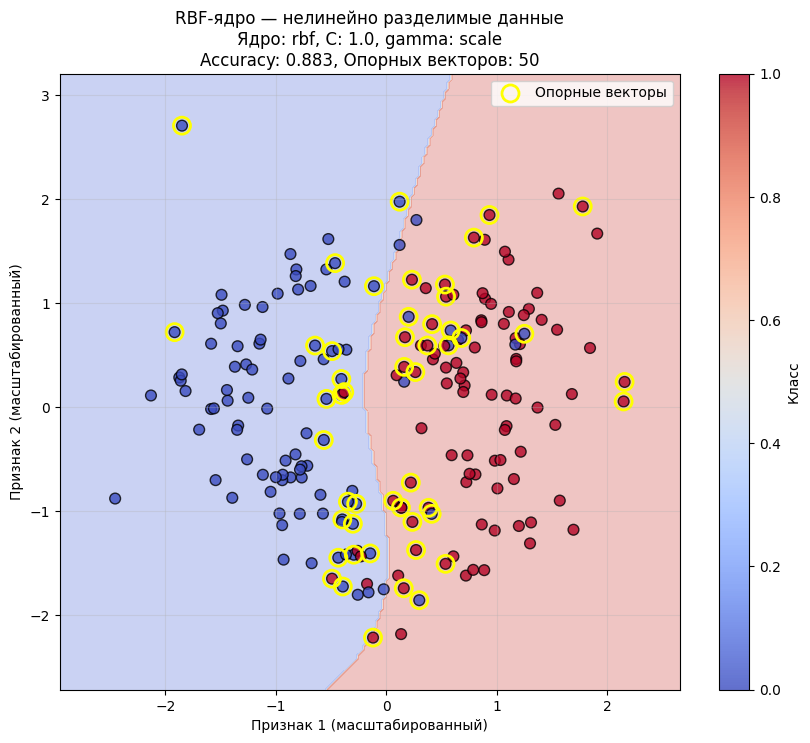

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: rbf
Параметры: C=1.0, gamma=scale
Точность на тесте: 0.8833
Время обучения: 0.0020с
Количество опорных векторов: 50


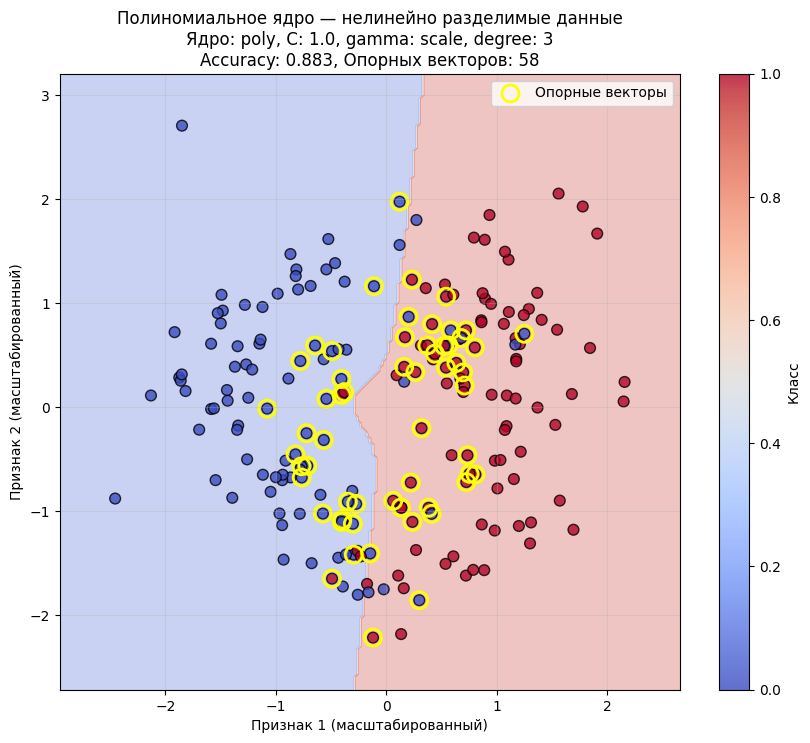

=== РЕЗУЛЬТАТЫ SVM ===
Ядро: poly
Параметры: C=1.0, gamma=scale, degree=3
Точность на тесте: 0.8833
Время обучения: 0.0020с
Количество опорных векторов: 58


In [17]:
# НЕЛИНЕЙНОМУ
# Линейное ядро
model_linear_3, acc_linear_3, time_linear_3 = train_svm_and_plot_decision_boundary(
    X_nonlinear, y_nonlinear, 
    kernel='linear', 
    C=1.0,
    title='Линейное ядро — нелинейно разделимые данные'
)

# RBF ядро
model_rbf_3, acc_rbf_3, time_rbf_3 = train_svm_and_plot_decision_boundary(
    X_nonlinear, y_nonlinear, 
    kernel='rbf', 
    C=1.0, gamma='scale',
    title='RBF-ядро — нелинейно разделимые данные'
)

# Полиномиальное ядро
model_poly_3, acc_poly_3, time_poly_3 = train_svm_and_plot_decision_boundary(
    X_nonlinear, y_nonlinear, 
    kernel='poly', 
    C=1.0, gamma='scale', degree=3,
    title='Полиномиальное ядро — нелинейно разделимые данные'
)

### 4. Подбор гиперпараметров с GridSearchCV

Пример для одного набора данных:

In [18]:
# ЯЧЕЙКА 3: ПОДБОР ПАРАМЕТРОВ С GRIDSEARCHCV
print("=== ПОДБОР ПАРАМЕТРОВ ДЛЯ НЕЛИНЕЙНОГО НАБОРА ДАННЫХ ===")

# Масштабирование признаков
scaler = StandardScaler()
X_nonlinear_scaled = scaler.fit_transform(X_nonlinear)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_nonlinear_scaled, y_nonlinear, test_size=0.3, random_state=42
)

print(f"✅ Обучающая выборка: {X_train.shape}")
print(f"✅ Тестовая выборка: {X_test.shape}")

# Параметры для GridSearchCV
param_grid_nonlinear = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10, 'scale', 'auto'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Запуск GridSearchCV
grid_search_all = GridSearchCV(
    svm.SVC(random_state=42),
    param_grid_nonlinear,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV...")
start_time = time.time()
grid_search_all.fit(X_train, y_train)
search_time_all = time.time() - start_time

# Получаем результаты
best_params_all = grid_search_all.best_params_
best_score_all = grid_search_all.best_score_
best_model_all = grid_search_all.best_estimator_

# Оценка на тестовой выборке
y_pred_all = best_model_all.predict(X_test)
test_accuracy_all = accuracy_score(y_test, y_pred_all)

print(f"\n=== РЕЗУЛЬТАТЫ ПОДБОРА ===")
print(f"✅ Лучшие параметры: {best_params_all}")
print(f"✅ Точность на кросс-валидации: {best_score_all:.4f}")
print(f"✅ Точность на тесте: {test_accuracy_all:.4f}")
print(f"✅ Время подбора: {search_time_all:.2f} сек")
print(f"✅ Количество опорных векторов: {len(best_model_all.support_vectors_)}")

=== ПОДБОР ПАРАМЕТРОВ ДЛЯ НЕЛИНЕЙНОГО НАБОРА ДАННЫХ ===
✅ Обучающая выборка: (140, 2)
✅ Тестовая выборка: (60, 2)
Запуск GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== РЕЗУЛЬТАТЫ ПОДБОРА ===
✅ Лучшие параметры: {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}
✅ Точность на кросс-валидации: 0.9214
✅ Точность на тесте: 0.8833
✅ Время подбора: 22.61 сек
✅ Количество опорных векторов: 58


# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ ДЛЯ НЕЛИНЕЙНОГО НАБОРА

=== ВИЗУАЛИЗАЦИЯ ГРАНИЦЫ РЕШЕНИЯ И ОПОРНЫХ ВЕКТОРОВ ===


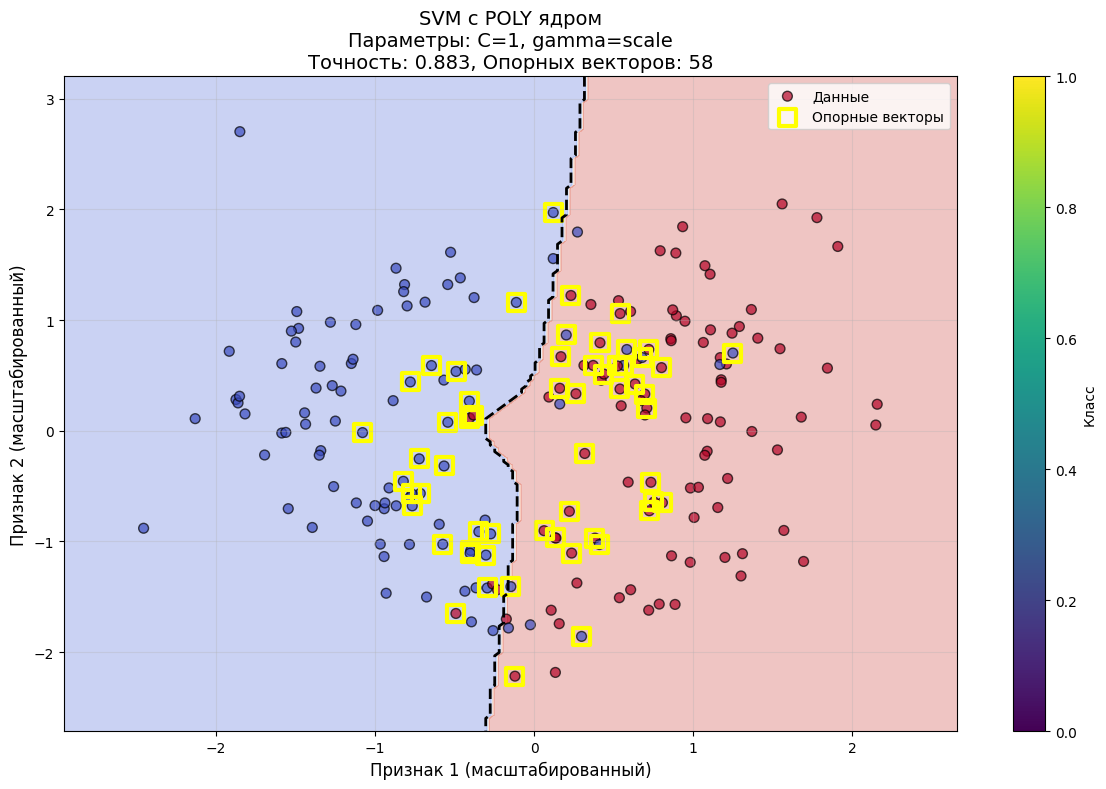

✅ Визуализация завершена!
🔵 Всего точек данных: 200
🟡 Опорных векторов: 58
📊 Доля опорных векторов: 29.00%
🎯 Точность модели: 0.883


In [21]:
# ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ
print("=== ВИЗУАЛИЗАЦИЯ ГРАНИЦЫ РЕШЕНИЯ И ОПОРНЫХ ВЕКТОРОВ ===")

# Создаем фигуру для визуализации
plt.figure(figsize=(12, 8))

# Создание сетки для построения границ
x_min, x_max = X_nonlinear_scaled[:, 0].min() - 0.5, X_nonlinear_scaled[:, 0].max() + 0.5
y_min, y_max = X_nonlinear_scaled[:, 1].min() - 0.5, X_nonlinear_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Предсказание для каждой точки сетки
Z = best_model_all.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 1. Рисуем фон с областями классов
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# 2. Рисуем границу решения (линия разделения)
plt.contour(xx, yy, Z, colors='black', linewidths=2, linestyles='--', levels=[0])

# 3. Рисуем все точки данных
plt.scatter(X_nonlinear_scaled[:, 0], X_nonlinear_scaled[:, 1], c=y_nonlinear, 
           cmap='coolwarm', edgecolors='k', s=50, alpha=0.7, label='Данные')

# 4. Выделяем опорные векторы
plt.scatter(best_model_all.support_vectors_[:, 0], best_model_all.support_vectors_[:, 1],
           s=150, facecolors='none', edgecolors='yellow', 
           linewidths=3, label='Опорные векторы', marker='s')

# Настройка графика
plt.colorbar(label='Класс')
plt.xlabel('Признак 1 (масштабированный)', fontsize=12)
plt.ylabel('Признак 2 (масштабированный)', fontsize=12)

# Заголовок с информацией
kernel_name = best_params_all['kernel'].upper()
title = f"SVM с {kernel_name} ядром\n"
title += f"Параметры: C={best_params_all['C']}, gamma={best_params_all['gamma']}\n"
title += f"Точность: {test_accuracy_all:.3f}, Опорных векторов: {len(best_model_all.support_vectors_)}"

plt.title(title, fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_decision_boundary_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Визуализация завершена!")
print(f"🔵 Всего точек данных: {len(X_nonlinear_scaled)}")
print(f"🟡 Опорных векторов: {len(best_model_all.support_vectors_)}")
print(f"📊 Доля опорных векторов: {len(best_model_all.support_vectors_)/len(X_nonlinear_scaled):.2%}")
print(f"🎯 Точность модели: {test_accuracy_all:.3f}")

# АНИМАЦИЯ ГРАНИЦЫ РЕШЕНИЯ ПРИ ИЗМЕНЕНИИ ПАРАМЕТРА

=== ВЛИЯНИЕ ПАРАМЕТРА C НА ГРАНИЦУ РЕШЕНИЯ ===


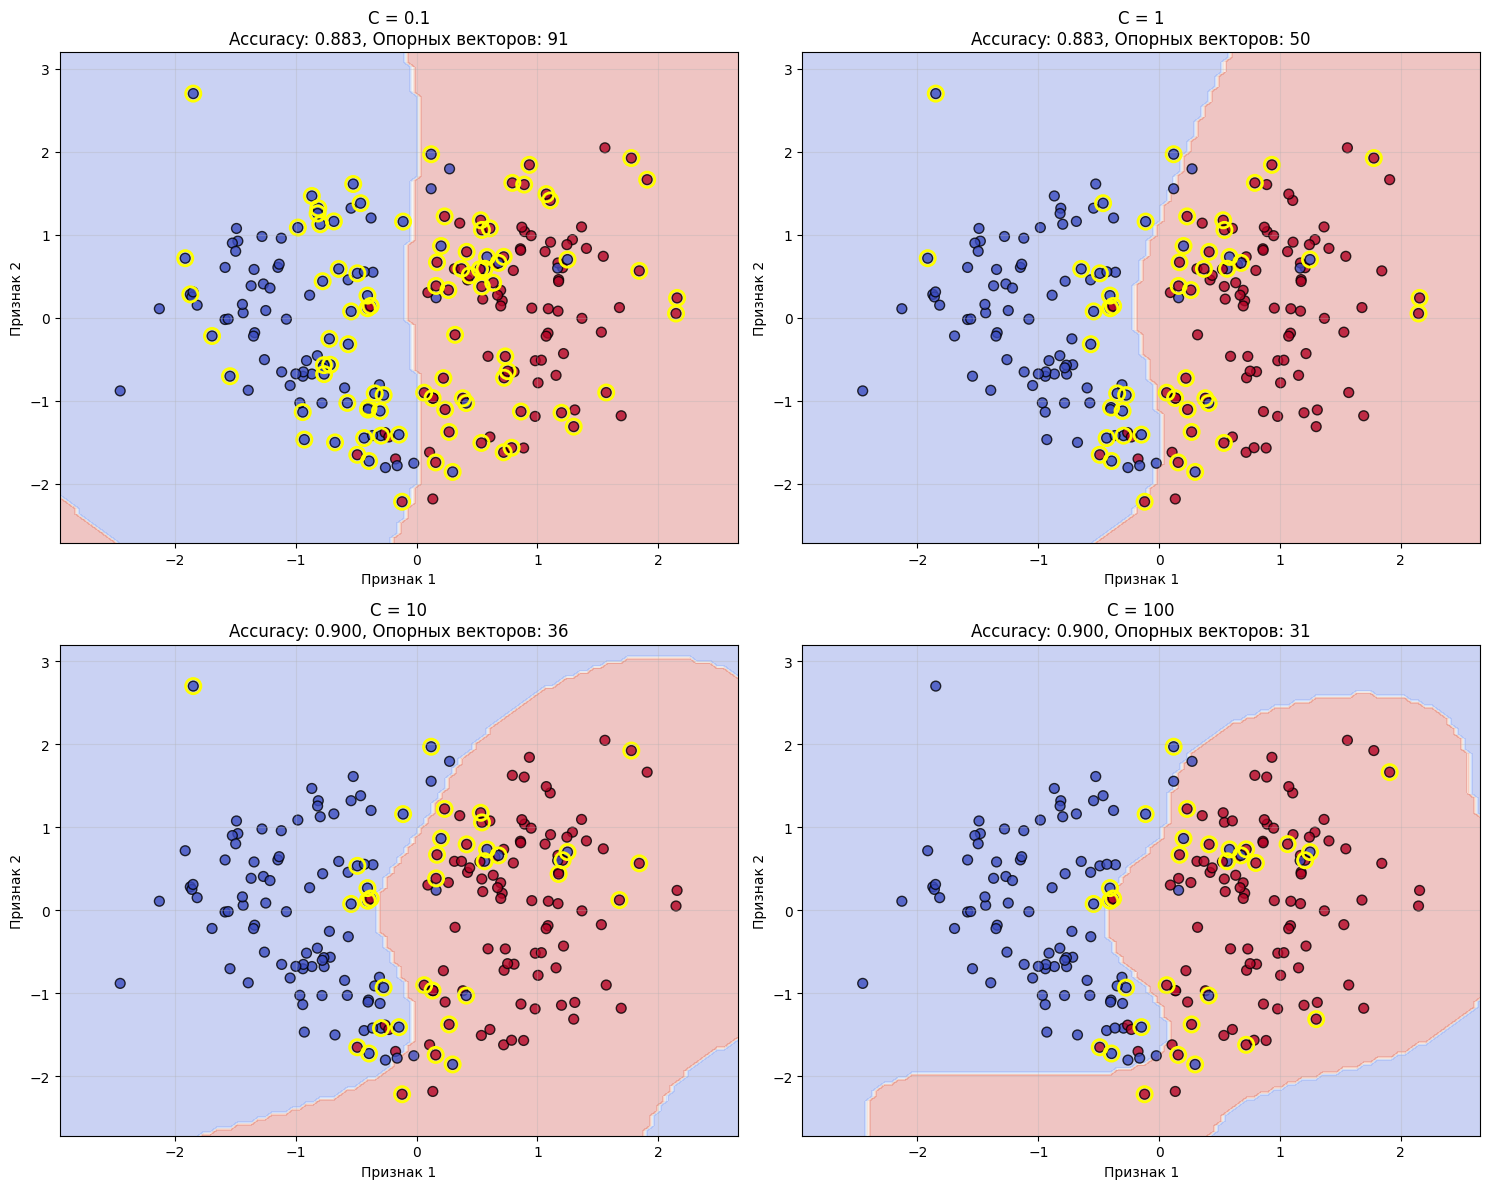

In [27]:
# 3. ВЛИЯНИЕ ПАРАМЕТРА C НА ГРАНИЦУ РЕШЕНИЯ
print("=== ВЛИЯНИЕ ПАРАМЕТРА C НА ГРАНИЦУ РЕШЕНИЯ ===")

C_values = [0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, C_val in enumerate(C_values):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Создаем и обучаем модель
    temp_model = svm.SVC(kernel='rbf', C=C_val, gamma=best_params_all['gamma'], random_state=42)
    temp_model.fit(X_train, y_train)
    
    # Визуализация
    x_min, x_max = X_nonlinear_scaled[:, 0].min() - 0.5, X_nonlinear_scaled[:, 0].max() + 0.5
    y_min, y_max = X_nonlinear_scaled[:, 1].min() - 0.5, X_nonlinear_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = temp_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_nonlinear_scaled[:, 0], X_nonlinear_scaled[:, 1], c=y_nonlinear, 
              cmap='coolwarm', edgecolors='k', s=50, alpha=0.8)
    ax.scatter(temp_model.support_vectors_[:, 0], temp_model.support_vectors_[:, 1],
              s=120, facecolors='none', edgecolors='yellow', linewidths=2)
    
    # Оценка точности
    y_pred_temp = temp_model.predict(X_test)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    
    ax.set_title(f'C = {C_val}\nAccuracy: {acc_temp:.3f}, Опорных векторов: {len(temp_model.support_vectors_)}', 
                fontsize=12)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_C_parameter_effect.png', dpi=300, bbox_inches='tight')
plt.show()

=== ДЕТАЛЬНЫЙ АНАЛИЗ ОПОРНЫХ ВЕКТОРОВ ===


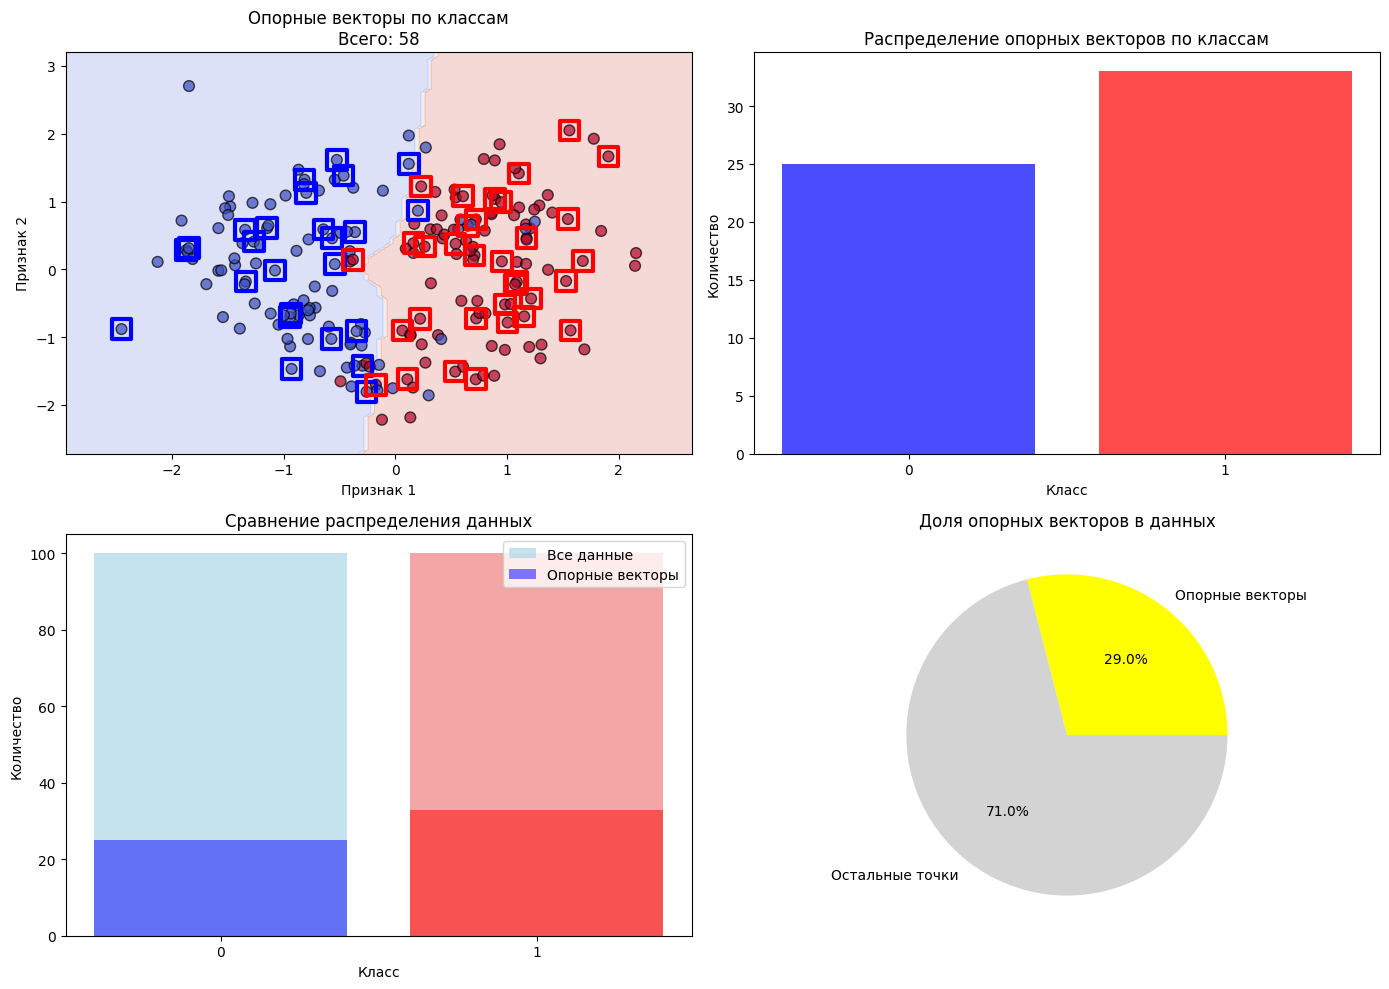


=== СТАТИСТИКА ОПОРНЫХ ВЕКТОРОВ ===
Всего опорных векторов: 58
Общее количество точек: 200
Доля опорных векторов: 0.290
Опорные векторы класса 0: 25
Опорные векторы класса 1: 33


In [28]:
# 4. ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ОПОРНЫХ ВЕКТОРОВ
print("=== ДЕТАЛЬНЫЙ АНАЛИЗ ОПОРНЫХ ВЕКТОРОВ ===")

plt.figure(figsize=(14, 10))

# Основной график с выделением опорных векторов
plt.subplot(2, 2, 1)
x_min, x_max = X_nonlinear_scaled[:, 0].min() - 0.5, X_nonlinear_scaled[:, 0].max() + 0.5
y_min, y_max = X_nonlinear_scaled[:, 1].min() - 0.5, X_nonlinear_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = best_model_all.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
scatter = plt.scatter(X_nonlinear_scaled[:, 0], X_nonlinear_scaled[:, 1], c=y_nonlinear, 
                     cmap='coolwarm', edgecolors='k', s=60, alpha=0.7)

# Выделяем опорные векторы разными цветами по классам
support_indices = best_model_all.support_
for i, idx in enumerate(support_indices):
    color = 'red' if y_nonlinear[idx] == 1 else 'blue'
    plt.scatter(X_nonlinear_scaled[idx, 0], X_nonlinear_scaled[idx, 1],
               s=200, facecolors='none', edgecolors=color, linewidths=3,
               marker='s')

plt.title(f'Опорные векторы по классам\nВсего: {len(support_indices)}', fontsize=12)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')

# Распределение опорных векторов по классам
plt.subplot(2, 2, 2)
support_labels = y_nonlinear[support_indices]
unique, counts = np.unique(support_labels, return_counts=True)
plt.bar(unique, counts, color=['blue', 'red'], alpha=0.7)
plt.title('Распределение опорных векторов по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(unique)

# Сравнение с общим распределением данных
plt.subplot(2, 2, 3)
all_labels = y_nonlinear
unique_all, counts_all = np.unique(all_labels, return_counts=True)
plt.bar(unique_all, counts_all, color=['lightblue', 'lightcoral'], alpha=0.7, label='Все данные')
plt.bar(unique, counts, color=['blue', 'red'], alpha=0.5, label='Опорные векторы')
plt.title('Сравнение распределения данных')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.legend()
plt.xticks(unique_all)

# Доля опорных векторов
plt.subplot(2, 2, 4)
support_ratio = len(support_indices) / len(X_nonlinear_scaled)
other_ratio = 1 - support_ratio
plt.pie([support_ratio, other_ratio], 
        labels=['Опорные векторы', 'Остальные точки'],
        colors=['yellow', 'lightgray'], autopct='%1.1f%%')
plt.title('Доля опорных векторов в данных')

plt.tight_layout()
plt.savefig('support_vectors_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n=== СТАТИСТИКА ОПОРНЫХ ВЕКТОРОВ ===")
print(f"Всего опорных векторов: {len(support_indices)}")
print(f"Общее количество точек: {len(X_nonlinear_scaled)}")
print(f"Доля опорных векторов: {support_ratio:.3f}")
print(f"Опорные векторы класса 0: {counts[0]}")
print(f"Опорные векторы класса 1: {counts[1]}")

## 5. Выводы

* Что такое опорный вектор и почему он важен?
Опорные векторы - это точки данных, находящиеся ближе всего к разделяющей гиперплоскости. Они критически важны потому что:

✅ Определяют положение и ориентацию разделяющей границы

✅ Только эти точки влияют на итоговую модель

✅ Позволяют эффективно использовать память (модель зависит только от опорных векторов)

✅ Определяют ширину зазора (margin) между классами

* В чём разница между линейным и нелинейным SVM?
Линейный SVM: Использует линейное ядро, работает только с линейно разделимыми данными

Нелинейный SVM: Использует ядра (RBF, полиномиальное) для отображения данных в пространство высшей размерности, где они становятся линейно разделимыми

* Как параметры C и gamma влияют на модель?
Параметр C (регуляризация):

Меньшие значения C → шире зазор, допускается больше ошибок, лучше обобщение

Большие значения C → уже зазор, стремление к нулю ошибок, риск переобучения

Параметр gamma (влияние точки):

Меньшие gamma → большее сходство, более гладкая граница

Большие gamma → более локализованное влияние, сложная граница

* Почему важно масштабировать признаки перед обучением SVM?
SVM чувствителен к масштабу признаков потому что:

⚠️ Алгоритм максимизирует зазор между классами

⚠️ Признаки с большим разбросом значений доминируют в решении

⚠️ Масштабирование обеспечивает равный вклад всех признаков